# ETAPA 04 - Otimização do Modelo e Entrega Final

## Projeto: Manutenção Preditiva de "Zero-Downtime"

**Disciplina:** Ciência de Dados  
**Curso:** Engenharia de Controle e Automação  
**Grupo:** E  

### Integrantes
- Bruno Alves Guirado
- Guilherme Nascimento
- Guilherme Fernando
- Lucas Guedes
- Pedro Henrique Matias

### Dataset utilizado
**AI4I 2020 Predictive Maintenance Dataset**

## 1. Objetivo da Etapa

Esta etapa tem como objetivo refinar tecnicamente o modelo desenvolvido na M3, buscando melhorar seu desempenho por meio de otimização de hiperparâmetros, validação cruzada e análise comparativa entre o modelo base e o modelo otimizado.

Além disso, esta fase consolida a entrega final do projeto, integrando modelagem, dashboard e organização profissional do repositório.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 2. Carregamento dos Dados

Nesta etapa, utilizamos a base tratada gerada após o processo de ETL, mantendo a mesma estrutura empregada na etapa de modelagem da M3.

In [4]:
df = pd.read_csv("../data/processed/dados_tratados.csv")
df.head()

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Seleção das Variáveis

A variável alvo permanece sendo `machine_failure`, enquanto as variáveis `udi` e `product_id` seguem descartadas por representarem identificadores sem relevância preditiva.

In [5]:
features = [
    "type",
    "air_temperature_[k]",
    "process_temperature_[k]",
    "rotational_speed_[rpm]",
    "torque_[nm]",
    "tool_wear_[min]"
]

target = "machine_failure"

X = df[features]
y = df[target]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (10000, 6)
Dimensão de y: (10000,)


## 4. Separação entre Treino e Teste

A base foi dividida em conjuntos de treino e teste, preservando a proporção das classes por meio da estratificação.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (8000, 6) (8000,)
Teste: (2000, 6) (2000,)


## 5. Pré-processamento

Foi mantido o pipeline de pré-processamento com codificação da variável categórica `type` e padronização das variáveis numéricas.

In [7]:
categorical_features = ["type"]
numeric_features = [
    "air_temperature_[k]",
    "process_temperature_[k]",
    "rotational_speed_[rpm]",
    "torque_[nm]",
    "tool_wear_[min]"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

## 6. Modelo Base da M3

Como modelo base da etapa anterior, foi utilizada uma **Árvore de Decisão**, selecionada com base no melhor F1-score entre os algoritmos testados.

In [8]:
baseline_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", baseline_model)
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

baseline_results = {
    "Modelo": "Árvore de Decisão Base",
    "Acurácia": accuracy_score(y_test, baseline_pred),
    "Precisão": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1-score": f1_score(y_test, baseline_pred, zero_division=0)
}

pd.DataFrame([baseline_results])

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Árvore de Decisão Base,0.978,0.714286,0.588235,0.645161


## 7. Otimização com GridSearchCV

Para melhorar o desempenho do modelo, foi realizada uma busca sistemática de hiperparâmetros com **GridSearchCV**, utilizando validação cruzada.

In [9]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [10]:
print("Melhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor F1-score médio na validação cruzada:")
print(grid_search.best_score_)

Melhores parâmetros:
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}

Melhor F1-score médio na validação cruzada:
0.6682956898174289


## 8. Modelo Otimizado

A seguir, o modelo otimizado é avaliado no conjunto de teste para comparação com o modelo base.

In [11]:
best_pipeline = grid_search.best_estimator_
optimized_pred = best_pipeline.predict(X_test)

optimized_results = {
    "Modelo": "Árvore de Decisão Otimizada",
    "Acurácia": accuracy_score(y_test, optimized_pred),
    "Precisão": precision_score(y_test, optimized_pred, zero_division=0),
    "Recall": recall_score(y_test, optimized_pred, zero_division=0),
    "F1-score": f1_score(y_test, optimized_pred, zero_division=0)
}

pd.DataFrame([optimized_results])

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Árvore de Decisão Otimizada,0.9785,0.671233,0.720588,0.695035


## 9. Comparação entre Modelo Base e Modelo Otimizado

In [12]:
comparison_df = pd.DataFrame([baseline_results, optimized_results])
comparison_df

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Árvore de Decisão Base,0.9780,0.714286,0.588235,0.645161
1,Árvore de Decisão Otimizada,0.9785,0.671233,0.720588,0.695035


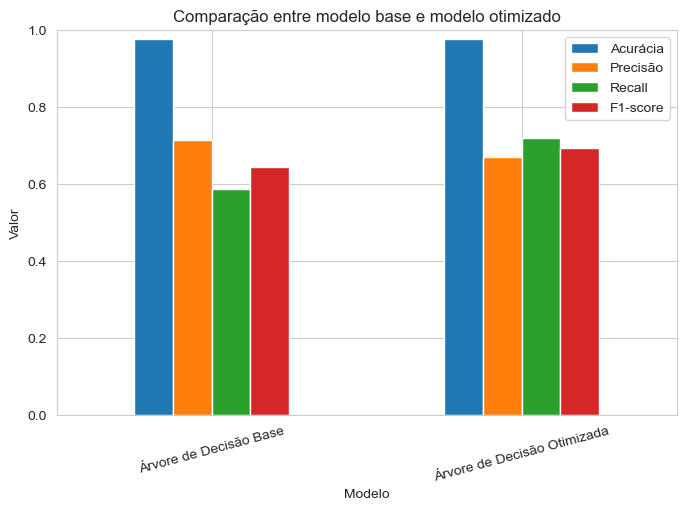

In [13]:
comparison_df.set_index("Modelo")[["Acurácia", "Precisão", "Recall", "F1-score"]].plot(kind="bar")
plt.title("Comparação entre modelo base e modelo otimizado")
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

## 10. Validação Cruzada

Além da avaliação no conjunto de teste, foi realizada validação cruzada para verificar a estabilidade do modelo otimizado.

In [14]:
cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("F1-score em cada dobra:", cv_scores)
print("F1-score médio:", cv_scores.mean())
print("Desvio padrão:", cv_scores.std())

F1-score em cada dobra: [0.63768116 0.44117647 0.35087719 0.24242424 0.64516129]
F1-score médio: 0.46346407114756083
Desvio padrão: 0.15836452977725354


## 11. Matriz de Confusão do Modelo Final

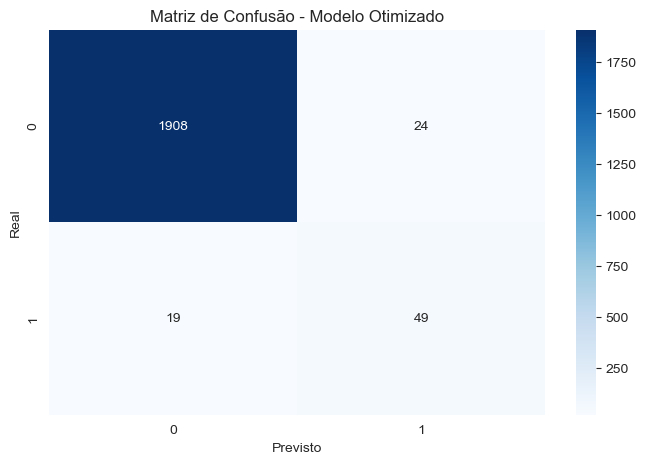

In [15]:
cm = confusion_matrix(y_test, optimized_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Modelo Otimizado")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 12. Relatório de Classificação do Modelo Final

In [16]:
print(classification_report(y_test, optimized_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.72      0.70        68

    accuracy                           0.98      2000
   macro avg       0.83      0.85      0.84      2000
weighted avg       0.98      0.98      0.98      2000



## 13. Salvamento do Modelo Final

In [17]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/modelo_final.pkl")
print("Modelo final salvo em ../models/modelo_final.pkl")

Modelo final salvo em ../models/modelo_final.pkl


## 14. Conclusão da Etapa

A etapa de otimização permitiu refinar o modelo desenvolvido anteriormente, utilizando busca de hiperparâmetros e validação cruzada para melhorar sua robustez e confiabilidade. A comparação entre o modelo base e o modelo otimizado mostrou se houve ganho de desempenho, especialmente em métricas mais relevantes para o problema, como o F1-score.

Com isso, o projeto passa a contar com uma solução mais madura tecnicamente, pronta para integração com o dashboard e para apresentação final no repositório do grupo.